In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print(f"\nFraud: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")
print(f"Legitimate: {(df['Class']==0).sum()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head()

Shape: (284807, 31)

Fraud: 492 (0.1727%)
Legitimate: 284315

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


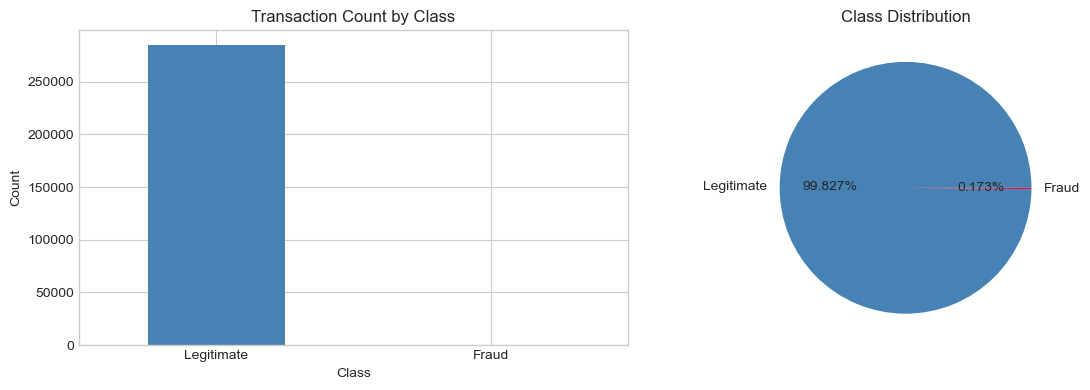

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

df['Class'].value_counts().plot(kind='pie', ax=axes[1], labels=['Legitimate', 'Fraud'],
                                 autopct='%1.3f%%', colors=['steelblue', 'crimson'])
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

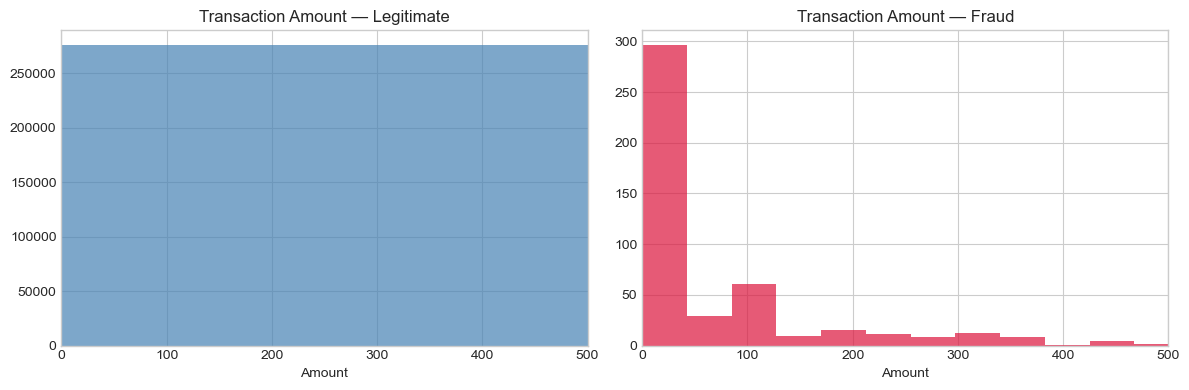

Legitimate — Mean: $88.29, Median: $22.00
Fraud      — Mean: $122.21, Median: $9.25


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Legitimate', color='steelblue')
axes[0].set_title('Transaction Amount — Legitimate')
axes[0].set_xlabel('Amount')
axes[0].set_xlim(0, 500)

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='crimson')
axes[1].set_title('Transaction Amount — Fraud')
axes[1].set_xlabel('Amount')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

print("Legitimate — Mean: ${:.2f}, Median: ${:.2f}".format(
    df[df['Class']==0]['Amount'].mean(), df[df['Class']==0]['Amount'].median()))
print("Fraud      — Mean: ${:.2f}, Median: ${:.2f}".format(
    df[df['Class']==1]['Amount'].mean(), df[df['Class']==1]['Amount'].median()))

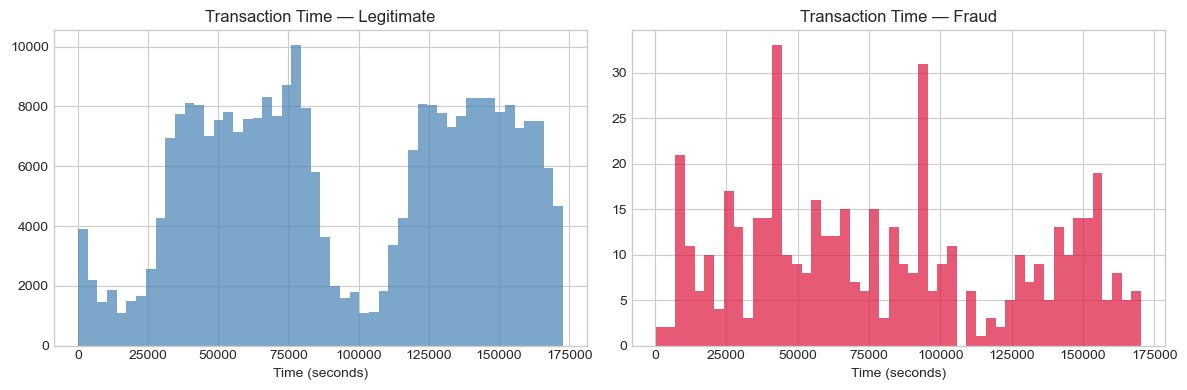

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.7, color='steelblue')
axes[0].set_title('Transaction Time — Legitimate')
axes[0].set_xlabel('Time (seconds)')

axes[1].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.7, color='crimson')
axes[1].set_title('Transaction Time — Fraud')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

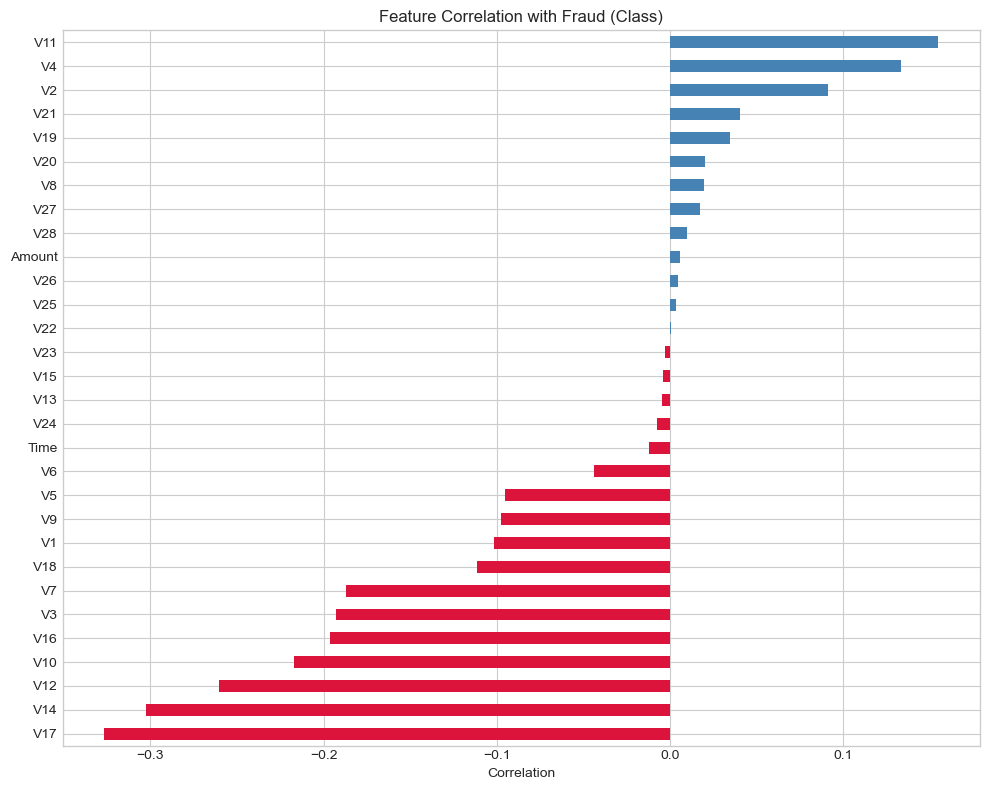


Top positive correlations:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top negative correlations:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [6]:
correlations = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['crimson' if x < 0 else 'steelblue' for x in correlations])
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print("\nTop positive correlations:")
print(correlations.tail(5))
print("\nTop negative correlations:")
print(correlations.head(5))

In [7]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time (V1-V28 are already PCA-scaled)
df['Amount_Scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_Scaled'] = StandardScaler().fit_transform(df[['Time']])

# Drop original Amount and Time
df = df.drop(['Amount', 'Time'], axis=1)

print("Final shape:", df.shape)
print("Columns:", list(df.columns))

Final shape: (284807, 31)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_Scaled', 'Time_Scaled']


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} samples — Fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test:  {len(X_test)} samples — Fraud: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Train: 227845 samples — Fraud: 394 (0.1729%)
Test:  56962 samples — Fraud: 98 (0.1720%)


In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# SMOTE: create synthetic fraud samples to balance the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== After SMOTE ===")
print(f"Train: {len(X_train_smote)} samples")
print(f"Legitimate: {(y_train_smote==0).sum()}")
print(f"Fraud: {(y_train_smote==1).sum()}")

# Also create an undersampled version for comparison
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

print(f"\n=== After Undersampling ===")
print(f"Train: {len(X_train_under)} samples")
print(f"Legitimate: {(y_train_under==0).sum()}")
print(f"Fraud: {(y_train_under==1).sum()}")

=== After SMOTE ===
Train: 454902 samples
Legitimate: 227451
Fraud: 227451

=== After Undersampling ===
Train: 788 samples
Legitimate: 394
Fraud: 394


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              roc_curve, f1_score, precision_score, recall_score)

# Train on SMOTE-balanced data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (SMOTE) ===")
print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, lr_proba):.4f}")
print(f"\n{classification_report(y_test, lr_preds, target_names=['Legitimate','Fraud'])}")

=== Logistic Regression (SMOTE) ===
Precision: 0.0581
Recall:    0.9184
F1 Score:  0.1094
AUC-ROC:   0.9698

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (SMOTE) ===")
print(f"Precision: {precision_score(y_test, rf_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_proba):.4f}")
print(f"\n{classification_report(y_test, rf_preds, target_names=['Legitimate','Fraud'])}")

=== Random Forest (SMOTE) ===
Precision: 0.6480
Recall:    0.8265
F1 Score:  0.7265
AUC-ROC:   0.9779

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.65      0.83      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.91      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                     scale_pos_weight=1, random_state=42,
                     use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost (SMOTE) ===")
print(f"Precision: {precision_score(y_test, xgb_preds):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"\n{classification_report(y_test, xgb_preds, target_names=['Legitimate','Fraud'])}")

=== XGBoost (SMOTE) ===
Precision: 0.3613
Recall:    0.8776
F1 Score:  0.5119
AUC-ROC:   0.9757

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.36      0.88      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.76     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
results = []

for name, Xtr, ytr in [('No Resampling', X_train, y_train),
                         ('SMOTE', X_train_smote, y_train_smote),
                         ('Undersampling', X_train_under, y_train_under)]:
    model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(Xtr, ytr)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Strategy': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

     Strategy  Precision  Recall  F1 Score  AUC-ROC
No Resampling     0.9412  0.8163    0.8743   0.9770
        SMOTE     0.6480  0.8265    0.7265   0.9779
Undersampling     0.0431  0.8980    0.0822   0.9758


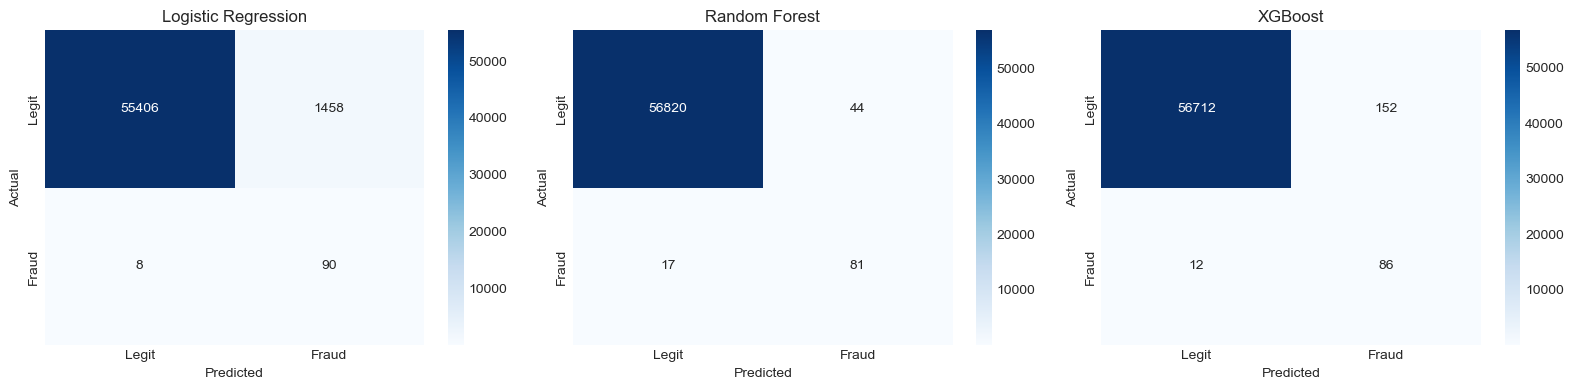

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in zip(axes,
                            [lr_preds, rf_preds, xgb_preds],
                            ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

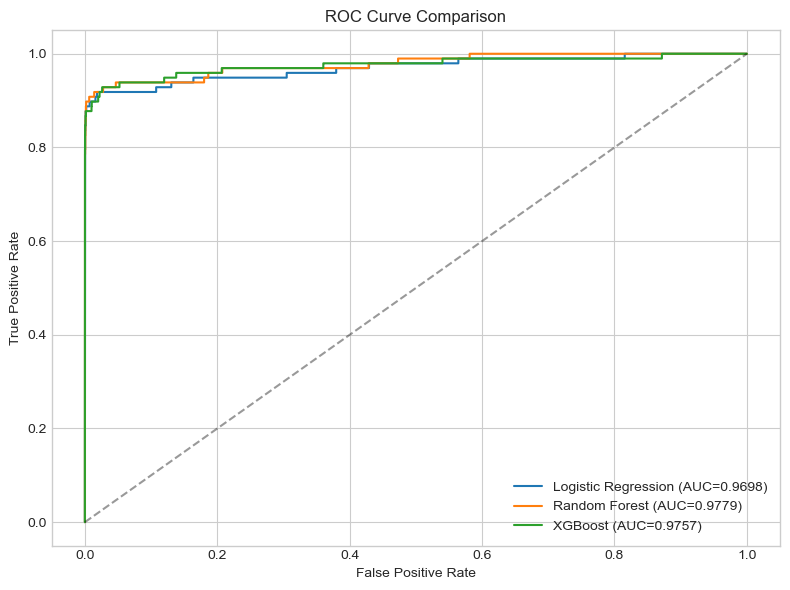

In [15]:
plt.figure(figsize=(8, 6))

for proba, name in zip([lr_proba, rf_proba, xgb_proba],
                        ['Logistic Regression', 'Random Forest', 'XGBoost']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

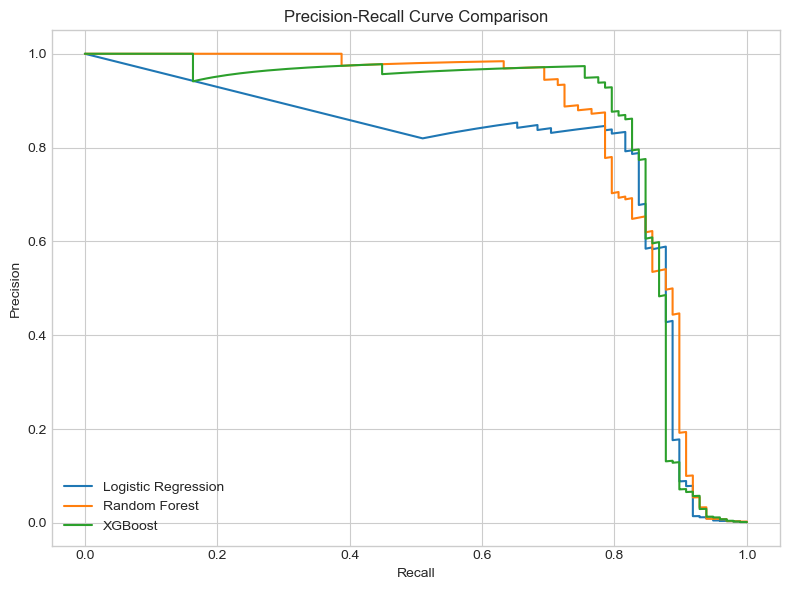

In [16]:
plt.figure(figsize=(8, 6))

for proba, name in zip([lr_proba, rf_proba, xgb_proba],
                        ['Logistic Regression', 'Random Forest', 'XGBoost']):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [precision_score(y_test, p) for p in [lr_preds, rf_preds, xgb_preds]],
    'Recall': [recall_score(y_test, p) for p in [lr_preds, rf_preds, xgb_preds]],
    'F1 Score': [f1_score(y_test, p) for p in [lr_preds, rf_preds, xgb_preds]],
    'AUC-ROC': [roc_auc_score(y_test, p) for p in [lr_proba, rf_proba, xgb_proba]]
}).round(4)

print(summary.to_string(index=False))

              Model  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression     0.0581  0.9184    0.1094   0.9698
      Random Forest     0.6480  0.8265    0.7265   0.9779
            XGBoost     0.3613  0.8776    0.5119   0.9757


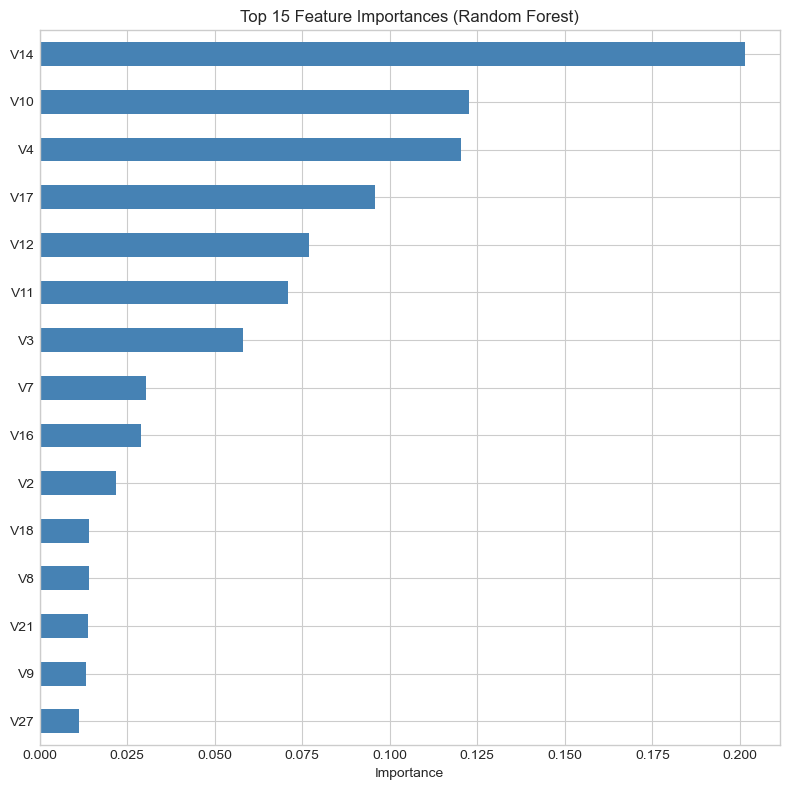

In [18]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importance.tail(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [39]:
import joblib

# Retrain RF on original (no resampling) training data
best_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

best_preds = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

print("=== Final Model: Random Forest (No Resampling) ===")
print(f"Precision: {precision_score(y_test, best_preds):.4f}")
print(f"Recall:    {recall_score(y_test, best_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, best_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, best_proba):.4f}")

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(list(X.columns), 'feature_cols.pkl')
print("\nModel and features saved.")

=== Final Model: Random Forest (No Resampling) ===
Precision: 0.9412
Recall:    0.8163
F1 Score:  0.8743
AUC-ROC:   0.9770

Model and features saved.
